# Classification Tree 

Implementasi Classification Tree menggunakan **Gini Impurity** sebagai kriteria split.  
Dilengkapi dengan evaluasi **Accuracy, Precision, Recall, F1-Score** dan **Training Progress Tracking**.

---

## 1. Import Library

In [9]:
import math
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Library untuk evaluasi metrik dan tracking
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil di-import!")

Library berhasil di-import!


---
## 2. Struktur Node

- Jika node adalah **percabangan (decision)**: hanya terisi `feature_index`, `threshold`, `left`, `right`
- Jika node adalah **leaf**: `value` terisi (class label)
- `is_leaf()` untuk mengecek apakah node adalah leaf

In [10]:
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None

print("Class Node berhasil didefinisikan.")

Class Node berhasil didefinisikan.


---
## 3. Class DecisionTreeClassifier (Manual)

Implementasi manual decision tree classifier dengan Gini Impurity.

**Hyperparameter:**
- `max_depth`: kedalaman maksimum tree
- `min_samples_split`: jumlah minimum data pada node agar bisa dipecah

**Tambahan:**
- `training_log`: menyimpan progress training per depth (jumlah node, rata-rata gini)

In [11]:
class DecisionTreeClassifier:
    # Hyperparameter
    # max_depth: kedalaman maksimum tree
    # min_samples_split: jumlah minimum data pada node agar node bisa dipecah lagi
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        # Tracking progress training
        self.training_log = []  # list of dict per depth
        self._depth_stats = {}  # {depth: {'nodes': 0, 'gains': [], 'samples': [], 'leaves': 0}}


    # ENTRY POINT
    # Mapping feature dan class label
    def fit(self, X, y):
        self._depth_stats = {}
        data = [row + [label] for row, label in zip(X, y)]
        self.root = self.build_tree(data, depth=0)
        # Compile training log dari depth_stats
        self.training_log = []
        for d in sorted(self._depth_stats.keys()):
            stats = self._depth_stats[d]
            avg_gain = np.mean(stats['gains']) if stats['gains'] else 0.0
            self.training_log.append({
                'depth': d,
                'total_nodes': stats['nodes'],
                'leaf_nodes': stats['leaves'],
                'decision_nodes': stats['nodes'] - stats['leaves'],
                'avg_gini_gain': round(avg_gain, 6),
                'avg_samples': round(np.mean(stats['samples']), 2) if stats['samples'] else 0
            })


    # Predict sebanyak jumlah data yang ada
    def predict(self, X):
        return [self.predict_one(row, self.root) for row in X]

    # Selama bukan leaf, ke node lain
    def predict_one(self, row, node):
        while not node.is_leaf():
            if row[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value



    # Membuat tree 
    # 1. cek status (apa sudah diujung(leaf))
    # 2. cari strategi bestsplit data
    # 3. potong data, buat branch baru
    # 4. constract tree
    def build_tree(self, data, depth):
        # Mengambil y saja
        y = [row[-1] for row in data]

        num_samples = len(y)
        num_labels = len(set(y))

        # Inisialisasi tracking untuk depth ini
        if depth not in self._depth_stats:
            self._depth_stats[depth] = {'nodes': 0, 'gains': [], 'samples': [], 'leaves': 0}

        self._depth_stats[depth]['nodes'] += 1
        self._depth_stats[depth]['samples'].append(num_samples)

        # Base condition: sudah melebihi depth max
        #                 sudah murni (num_labels = 1)
        #                 mencapai min sample split
        # Return: node dengan most common label
        # LEAF
        if (
            depth >= self.max_depth
            or num_labels == 1
            or num_samples < self.min_samples_split
        ):
            self._depth_stats[depth]['leaves'] += 1
            return Node(value=self.most_common_label(y))



        # Mencari split data terbaik
        best_feature, best_threshold, best_gain = self.best_split(data)
        
        # jika split tidak membuat kelompok makin murni, buat leaf
        if best_gain == 0:
            self._depth_stats[depth]['leaves'] += 1
            return Node(value=self.most_common_label(y))

        # Track gain
        self._depth_stats[depth]['gains'].append(best_gain)

        # Lakukan split data branch kiri dan kanan
        left_data, right_data = self.split(data, best_feature, best_threshold)
        
        # Membuat branch baru
        left_child = self.build_tree(left_data, depth + 1)
        right_child = self.build_tree(right_data, depth + 1)
        
        # Membuat node baru
        return Node(best_feature, best_threshold, left_child, right_child)



    # Split function, brute force untuk dapat split terbaik
    
    def best_split(self, data):
        best_gain = -1
        best_feature = None
        best_threshold = None

        # Menghitung gini berdasarkan fitur yang ada
        n_features = len(data[0]) - 1
        currentgini = self.gini([row[-1] for row in data])

        # Mengambil unique data untuk dilakukan perhitungan gini impurity
        # threshold dihitung dengan mengambil range tengah
        for feature_index in range(n_features):
            values = sorted(set(row[feature_index] for row in data))
            # jika hanya 1 nilai (tidak ada range)
            # tidak perlu dihitung mid point, ke iterasi berikut
            if len(values) == 1: 
                continue
            
            # Mencari mid point dari setiap 2 titik
            thresholds = [(values[i] + values[i + 1]) / 2 for i in range(len(values) - 1)]


            # iterasi split untuk semua titik mid point
            for threshold in thresholds:
                left_data, right_data = self.split(data, feature_index, threshold)
                # jika salah satu side kosong, iterasi berikutnya
                if not left_data or not right_data:
                    continue

                # ambil label dari sisi kiri dan kanan
                # lalu hitung gain berdasarkan currentgini 
                left_y = [row[-1] for row in left_data]
                right_y = [row[-1] for row in right_data]
                gain = self.total_gini_impurity(currentgini, left_y, right_y)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_index
                    best_threshold = threshold

        if best_gain < 0:
            best_gain = 0

        return best_feature, best_threshold, best_gain



    # Membagi data berdasarkan index dan threshold yang ditentukan
    def split(self, data, feature_index, threshold):
        left = [row for row in data if row[feature_index] <= threshold]
        right = [row for row in data if row[feature_index] > threshold]
        return left, right



    # Menghitung gini impurity (0 - .5)
    # 0 murni, data dalam 1 kelompok classnya sama
    # makin .5 berarti makin campuran
    # Menentukan best split 
    # Gini Impurity (D) = 1 - sum (p_i^2)
    def gini(self, labels):
        counts = Counter(labels)
        n = len(labels)
        if n == 0:
            return 0
        impurity = 1.0
        for count in counts.values():
            p = count / n
            impurity -= p ** 2
        return impurity



    # Menghitung gain (skor seberapa berkurangnya gini after split)
    # dihitung dengan selisih current gini (parent) dengan
    # total dari perkalian weight dan gini tiap sisi (children)
    def total_gini_impurity(self, parentgini, left_y, right_y):
        n = len(left_y) + len(right_y)
        weight_left = len(left_y) / n
        weight_right = len(right_y) / n
        childgini = weight_left * self.gini(left_y) + weight_right * self.gini(right_y)
        return parentgini - childgini



    # Return label terbanyak dalam node (jika ada)
    # return 1 label paling banyak, index ke 0 dari list label, 
    # dan index ke 0 dari tuple  (ambil string label)
    def most_common_label(self, labels):
        return Counter(labels).most_common(1)[0][0]


print("Class DecisionTreeClassifier berhasil didefinisikan.")

Class DecisionTreeClassifier berhasil didefinisikan.


---
## 4. Fungsi Visualisasi Tree

In [12]:
def plot_tree(node, feature_names, x=0, y=0, dx=2.5, depth=0, ax=None):
    # buat canvas
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 8))
        ax.axis("off")

    # jika leaf, print class value
    # jika bukan leaf, print feature dan threshold
    if node.is_leaf():
        text = f"Class: {node.value}"
    else:
        feature = feature_names[node.feature_index]
        text = f"{feature} <= {node.threshold:.2f}"

    # Menggambar box text
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round", facecolor="lightblue")
    )

    # Menggambar layered tree
    if not node.is_leaf():
        left_x = x - dx / (depth + 1)
        right_x = x + dx / (depth + 1)
        child_y = y - 1.5

        # menentukan warna dan jenis line penghubung
        ax.plot([x, left_x], [y, child_y], "k-")
        ax.plot([x, right_x], [y, child_y], "k-")

        # visualisasi tree, ambil dari class node
        plot_tree(node.left, feature_names, left_x, child_y, dx, depth + 1, ax)
        plot_tree(node.right, feature_names, right_x, child_y, dx, depth + 1, ax)

    return ax

print("Fungsi plot_tree berhasil didefinisikan.")

Fungsi plot_tree berhasil didefinisikan.


---
## 5. Fungsi Evaluasi Metrik

Menghitung **Accuracy, Precision, Recall, F1-Score** menggunakan sklearn dan menampilkan **Confusion Matrix**.

In [13]:
def evaluate_model(y_true, y_pred, title="Evaluation"):
    """
    Menghitung dan menampilkan metrik evaluasi:
    - Accuracy
    - Precision (weighted)
    - Recall (weighted)
    - F1-Score (weighted)
    - Classification Report
    - Confusion Matrix
    """
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}  ({prec*100:.2f}%)")
    print(f"  Recall    : {rec:.4f}  ({rec*100:.2f}%)")
    print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
    
    print(f"\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    # Confusion Matrix Visualization
    labels = sorted(set(y_true + y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'Confusion Matrix - {title}', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax)
    
    tick_marks = range(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(labels)
    
    # Menampilkan angka di setiap cell
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=12)
    
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1}

print("Fungsi evaluate_model berhasil didefinisikan.")

Fungsi evaluate_model berhasil didefinisikan.


---
## 6. Fungsi Training Progress Tracking

Menampilkan progress training per depth: jumlah node, leaf, decision node, rata-rata Gini Gain, dan rata-rata jumlah sampel.

In [14]:
def show_training_progress(clf, title="Training Progress"):
    """
    Menampilkan tabel dan visualisasi progress training dari model.
    Informasi per depth:
    - Total nodes
    - Leaf nodes
    - Decision nodes
    - Average Gini Gain
    - Average samples per node
    """
    if not clf.training_log:
        print("Belum ada training log. Jalankan fit() terlebih dahulu.")
        return
    
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    
    # Tabel progress
    df_log = pd.DataFrame(clf.training_log)
    print(f"\n{df_log.to_string(index=False)}\n")
    
    # Summary
    total_nodes = sum(log['total_nodes'] for log in clf.training_log)
    total_leaves = sum(log['leaf_nodes'] for log in clf.training_log)
    total_decisions = sum(log['decision_nodes'] for log in clf.training_log)
    max_depth_reached = max(log['depth'] for log in clf.training_log)
    
    print(f"  Total Nodes     : {total_nodes}")
    print(f"  Leaf Nodes      : {total_leaves}")
    print(f"  Decision Nodes  : {total_decisions}")
    print(f"  Max Depth       : {max_depth_reached}")
    print(f"  Max Depth (set) : {clf.max_depth}")
    
    # Visualisasi
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    depths = [log['depth'] for log in clf.training_log]
    
    # Plot 1: Nodes per depth
    axes[0].bar(depths, 
                [log['decision_nodes'] for log in clf.training_log], 
                label='Decision Nodes', color='steelblue', alpha=0.8)
    axes[0].bar(depths, 
                [log['leaf_nodes'] for log in clf.training_log], 
                bottom=[log['decision_nodes'] for log in clf.training_log],
                label='Leaf Nodes', color='coral', alpha=0.8)
    axes[0].set_xlabel('Depth')
    axes[0].set_ylabel('Jumlah Node')
    axes[0].set_title('Node Distribution per Depth')
    axes[0].legend()
    axes[0].set_xticks(depths)
    
    # Plot 2: Average Gini Gain per depth
    gains = [log['avg_gini_gain'] for log in clf.training_log]
    axes[1].plot(depths, gains, 'o-', color='green', linewidth=2, markersize=8)
    axes[1].fill_between(depths, gains, alpha=0.2, color='green')
    axes[1].set_xlabel('Depth')
    axes[1].set_ylabel('Average Gini Gain')
    axes[1].set_title('Average Gini Gain per Depth')
    axes[1].set_xticks(depths)
    
    # Plot 3: Average samples per depth
    samples = [log['avg_samples'] for log in clf.training_log]
    axes[2].plot(depths, samples, 's-', color='purple', linewidth=2, markersize=8)
    axes[2].fill_between(depths, samples, alpha=0.2, color='purple')
    axes[2].set_xlabel('Depth')
    axes[2].set_ylabel('Average Samples')
    axes[2].set_title('Average Samples per Depth')
    axes[2].set_xticks(depths)
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("Fungsi show_training_progress berhasil didefinisikan.")

Fungsi show_training_progress berhasil didefinisikan.


---
## 7. Fungsi Depth Tuning Analysis

Melakukan training dengan berbagai `max_depth` dan membandingkan performa untuk menentukan depth optimal.

In [15]:
def depth_tuning_analysis(X_train, y_train, X_test, y_test, max_depth_range=range(1, 11)):
    """
    Analisis performa model pada berbagai max_depth.
    Menampilkan grafik Accuracy, Precision, Recall, F1-Score vs max_depth.
    """
    results = []
    
    for depth in max_depth_range:
        clf = DecisionTreeClassifier(max_depth=depth)
        clf.fit(X_train, y_train)
        
        # Evaluasi train
        y_pred_train = clf.predict(X_train)
        acc_train = accuracy_score(y_train, y_pred_train)
        
        # Evaluasi test
        y_pred_test = clf.predict(X_test)
        acc_test = accuracy_score(y_test, y_pred_test)
        prec_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
        rec_test = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
        f1_test = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
        
        results.append({
            'max_depth': depth,
            'train_accuracy': acc_train,
            'test_accuracy': acc_test,
            'test_precision': prec_test,
            'test_recall': rec_test,
            'test_f1_score': f1_test
        })
    
    df_results = pd.DataFrame(results)
    print("\n--- Depth Tuning Results ---")
    print(df_results.to_string(index=False))
    
    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Plot 1: Train vs Test Accuracy
    axes[0].plot(df_results['max_depth'], df_results['train_accuracy'], 'o-', 
                label='Train Accuracy', color='blue', linewidth=2)
    axes[0].plot(df_results['max_depth'], df_results['test_accuracy'], 's-', 
                label='Test Accuracy', color='red', linewidth=2)
    axes[0].set_xlabel('Max Depth')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Train vs Test Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Test Metrics
    axes[1].plot(df_results['max_depth'], df_results['test_accuracy'], 'o-', 
                label='Accuracy', linewidth=2)
    axes[1].plot(df_results['max_depth'], df_results['test_precision'], 's-', 
                label='Precision', linewidth=2)
    axes[1].plot(df_results['max_depth'], df_results['test_recall'], '^-', 
                label='Recall', linewidth=2)
    axes[1].plot(df_results['max_depth'], df_results['test_f1_score'], 'D-', 
                label='F1-Score', linewidth=2)
    axes[1].set_xlabel('Max Depth')
    axes[1].set_ylabel('Score')
    axes[1].set_title('Test Metrics per Depth')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Best depth
    best_idx = df_results['test_f1_score'].idxmax()
    best_depth = df_results.loc[best_idx, 'max_depth']
    print(f"\n>> Best max_depth berdasarkan F1-Score (test): {best_depth}")
    
    return df_results

print("Fungsi depth_tuning_analysis berhasil didefinisikan.")

Fungsi depth_tuning_analysis berhasil didefinisikan.


---
---
# START 1: Dataset Makro

Dataset makro menggunakan **sdss_dummy_classification.csv** dengan **35 fitur** (u, g, r, i, z, modelFlux, petroRad, petroFlux, petroR50, psfMag, expAB) dan target **subclass**.

---

### 8a. Load Dataset Makro

In [30]:
# Baca dataset CSV makro
df_makro = pd.read_csv("dataMakro.csv")

print(f"Shape dataset: {df_makro.shape}")
print(f"Kolom: {list(df_makro.columns)}")
print(f"\nDistribusi target (subclass):")
print(df_makro['subclass'].value_counts())
print(f"\n{df_makro.head()}")

Shape dataset: (97478, 37)
Kolom: ['u', 'g', 'r', 'i', 'z', 'modelFlux_u', 'modelFlux_g', 'modelFlux_r', 'modelFlux_i', 'modelFlux_z', 'petroRad_u', 'petroRad_g', 'petroRad_i', 'petroRad_r', 'petroRad_z', 'petroFlux_u', 'petroFlux_g', 'petroFlux_i', 'petroFlux_r', 'petroFlux_z', 'petroR50_u', 'petroR50_g', 'petroR50_i', 'petroR50_r', 'petroR50_z', 'psfMag_u', 'psfMag_r', 'psfMag_g', 'psfMag_i', 'psfMag_z', 'expAB_u', 'expAB_g', 'expAB_r', 'expAB_i', 'expAB_z', 'subclass', 'redshift_err']

Distribusi target (subclass):
subclass
STARFORMING    73518
STARBURST      23960
Name: count, dtype: int64

          u         g         r         i         z  modelFlux_u  modelFlux_g  \
0  21.73818  20.26633  19.32409  18.64037  18.23833     2.007378     7.823640   
1  20.66761  19.32016  18.67888  18.24693  18.04122     5.403369    18.703640   
2  23.63531  21.19671  19.92297  19.31443  18.68396     0.295693     3.318924   
3  20.12374  18.41520  17.47202  17.05297  16.72423     8.920645    43.044

### 8b. Persiapan Data Makro (Train-Test Split)

In [35]:
# Feature dan target
feature_names_makro = [
    'u', 'g', 'r', 'i', 'z',
    
    'modelFlux_u', 'modelFlux_g', 'modelFlux_r',
    'modelFlux_i', 'modelFlux_z',
    
    'petroRad_u', 'petroRad_g', 'petroRad_r',
    'petroRad_i', 'petroRad_z',
    
    'petroFlux_u', 'petroFlux_g', 'petroFlux_r',
    'petroFlux_i', 'petroFlux_z',
    
    'petroR50_u', 'petroR50_g', 'petroR50_r',
    'petroR50_i', 'petroR50_z',
    
    'psfMag_u', 'psfMag_g', 'psfMag_r',
    'psfMag_i', 'psfMag_z',
    
    'expAB_u', 'expAB_g', 'expAB_r',
    'expAB_i', 'expAB_z'
]

df_makro_limited = df_makro.sample(n=1000, random_state=37)

X_makro = df_makro[feature_names_makro].values.tolist()
y_makro = df_makro["subclass"].tolist()

# Train-test split (80% train, 20% test)
X_train_makro, X_test_makro, y_train_makro, y_test_makro = train_test_split(
    X_makro, y_makro, test_size=0.2, random_state=42, stratify=y_makro
)

print(f"Total data    : {len(X_makro)}")
print(f"Training data : {len(X_train_makro)}")
print(f"Testing data  : {len(X_test_makro)}")
print(f"Jumlah fitur  : {len(feature_names_makro)}")

Total data    : 97478
Training data : 77982
Testing data  : 19496
Jumlah fitur  : 35


### 8c. Training Model Makro

In [ ]:
# Training Classification Tree - Dataset Makro
clf_makro = DecisionTreeClassifier(max_depth=5)
clf_makro.fit(X_train_makro, y_train_makro)

print("Training selesai!")
print(f"Max depth (set): {clf_makro.max_depth}")

### 8d. Training Progress - Makro (salah)

In [ ]:
# Tampilkan progress training
show_training_progress(clf_makro, title="Training Progress - Dataset Makro")

### 8e. Prediksi & Evaluasi - Makro

In [ ]:
# Prediksi pada data test
y_pred_makro = clf_makro.predict(X_test_makro)

# Evaluasi metrik
metrics_makro = evaluate_model(y_test_makro, y_pred_makro, title="Dataset Makro (35 Fitur)")

### 8f. Visualisasi Tree - Makro

In [ ]:
# Visualisasi tree
plt.rc('font', size=8)
plot_tree(clf_makro.root, feature_names_makro)
plt.title("Classification Tree - Dataset Makro", fontsize=14, fontweight='bold')
plt.show()

### 8g. Depth Tuning - Makro

In [ ]:
# Analisis depth tuning
df_tuning_makro = depth_tuning_analysis(
    X_train_makro, y_train_makro, 
    X_test_makro, y_test_makro, 
    max_depth_range=range(1, 11)
)

---
---
# START 2: Dataset Mikro (Tracing)

Dataset mikro menggunakan **dataMikro.csv** dengan fitur **u, g, r** (X) dan target **subclass** (y).  
Semua data digunakan untuk training (**tanpa split**). Tujuan utama adalah untuk **tracing** proses decision tree.

---

### 9a. Load Dataset Mikro

In [16]:
# Baca dataset CSV mikro
df_mikro = pd.read_csv("dataMikro.csv")

print(f"Shape dataset: {df_mikro.shape}")
print(f"Kolom: {list(df_mikro.columns)}")
print(f"\nDistribusi target (subclass):")
print(df_mikro['subclass'].value_counts())
print(f"\n{df_mikro}")

Shape dataset: (10, 6)
Kolom: ['ID', 'u', 'g', 'r', 'subclass', 'redshift']

Distribusi target (subclass):
subclass
STARFORMING    6
STARBURST      4
Name: count, dtype: int64

   ID     u     g     r     subclass  redshift
0   1  18.5  17.2  16.6  STARFORMING      0.08
1   2  19.8  18.4  17.4  STARFORMING      0.11
2   3  21.7  20.2  19.3    STARBURST      0.23
3   4  20.6  19.3  18.6  STARFORMING      0.10
4   5  23.6  21.1  19.9    STARBURST      0.24
5   6  19.4  18.1  17.5  STARFORMING      0.11
6   7  20.2  18.6  17.7  STARFORMING      0.12
7   8  18.4  17.2  16.6    STARBURST      0.09
8   9  18.7  17.5  17.0  STARFORMING      0.08
9  10  19.8  18.4  17.4    STARBURST      0.22


### 9b. Persiapan Data Mikro

Semua data digunakan untuk training (tanpa split). Tujuan dataset mikro adalah untuk **tracing** proses decision tree.

In [17]:
# Feature: u, g, r | Target: subclass
feature_names_mikro = ['u', 'g', 'r']

X_mikro = df_mikro[feature_names_mikro].values.tolist()
y_mikro = df_mikro["subclass"].tolist()

# Semua data digunakan untuk training (untuk tracing)
print(f"Total data   : {len(X_mikro)}")
print(f"Jumlah fitur : {len(feature_names_mikro)}")
print(f"Fitur        : {feature_names_mikro}")
print(f"\nData X:")
for i, row in enumerate(X_mikro):
    print(f"  [{i+1}] u={row[0]}, g={row[1]}, r={row[2]}  ->  {y_mikro[i]}")

Total data   : 10
Jumlah fitur : 3
Fitur        : ['u', 'g', 'r']

Data X:
  [1] u=18.5, g=17.2, r=16.6  ->  STARFORMING
  [2] u=19.8, g=18.4, r=17.4  ->  STARFORMING
  [3] u=21.7, g=20.2, r=19.3  ->  STARBURST
  [4] u=20.6, g=19.3, r=18.6  ->  STARFORMING
  [5] u=23.6, g=21.1, r=19.9  ->  STARBURST
  [6] u=19.4, g=18.1, r=17.5  ->  STARFORMING
  [7] u=20.2, g=18.6, r=17.7  ->  STARFORMING
  [8] u=18.4, g=17.2, r=16.6  ->  STARBURST
  [9] u=18.7, g=17.5, r=17.0  ->  STARFORMING
  [10] u=19.8, g=18.4, r=17.4  ->  STARBURST


### 9c. Training Model Mikro

In [26]:
# Training Classification Tree - Dataset Mikro (semua data)
clf_mikro = DecisionTreeClassifier(max_depth=2)
clf_mikro.fit(X_mikro, y_mikro)

print("Training selesai!")
print(f"Max depth (set): {clf_mikro.max_depth}")

Training selesai!
Max depth (set): 2


### 9d. Training Progress - Mikro (salah)


  Training Progress - Dataset Mikro

 depth  total_nodes  leaf_nodes  decision_nodes  avg_gini_gain  avg_samples
     0            1           0               1       0.180000         10.0
     1            2           1               1       0.160714          5.0
     2            2           2               0       0.000000          4.0

  Total Nodes     : 5
  Leaf Nodes      : 3
  Decision Nodes  : 2
  Max Depth       : 2
  Max Depth (set) : 2


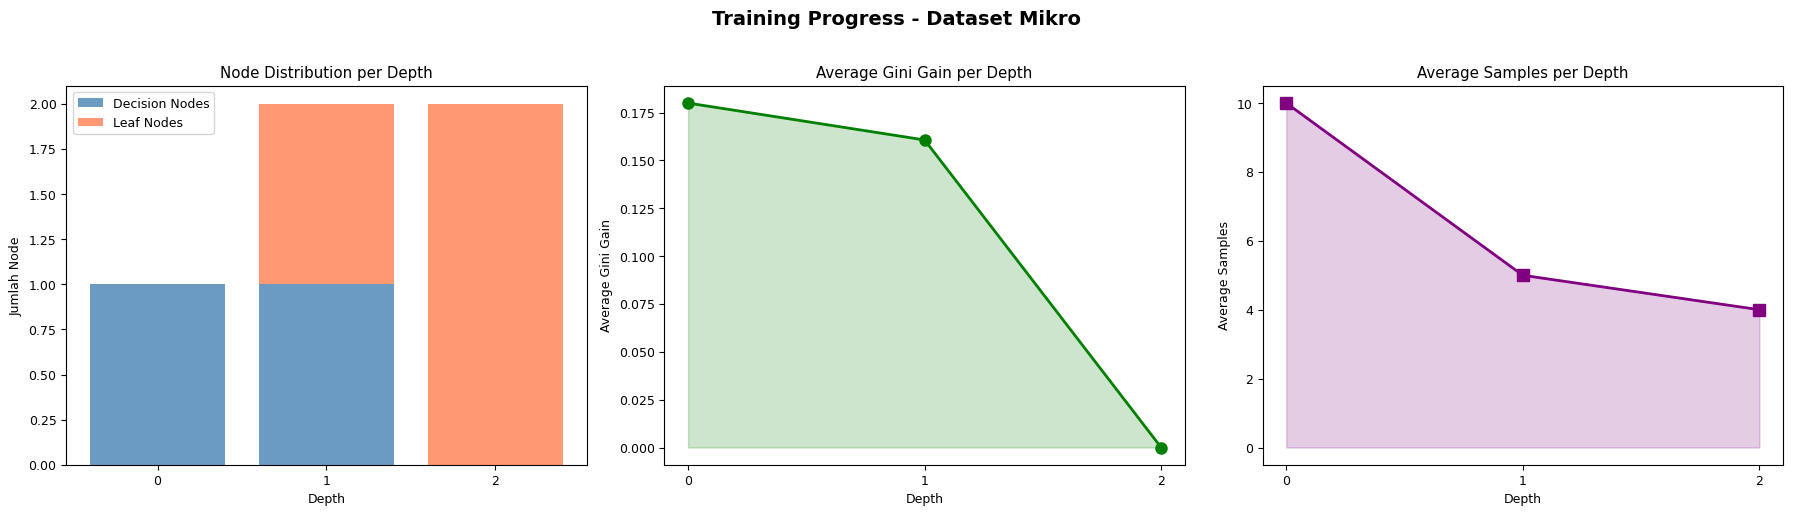

In [22]:
# Tampilkan progress training
show_training_progress(clf_mikro, title="Training Progress - Dataset Mikro")

### 9e. Visualisasi Tree - Mikro

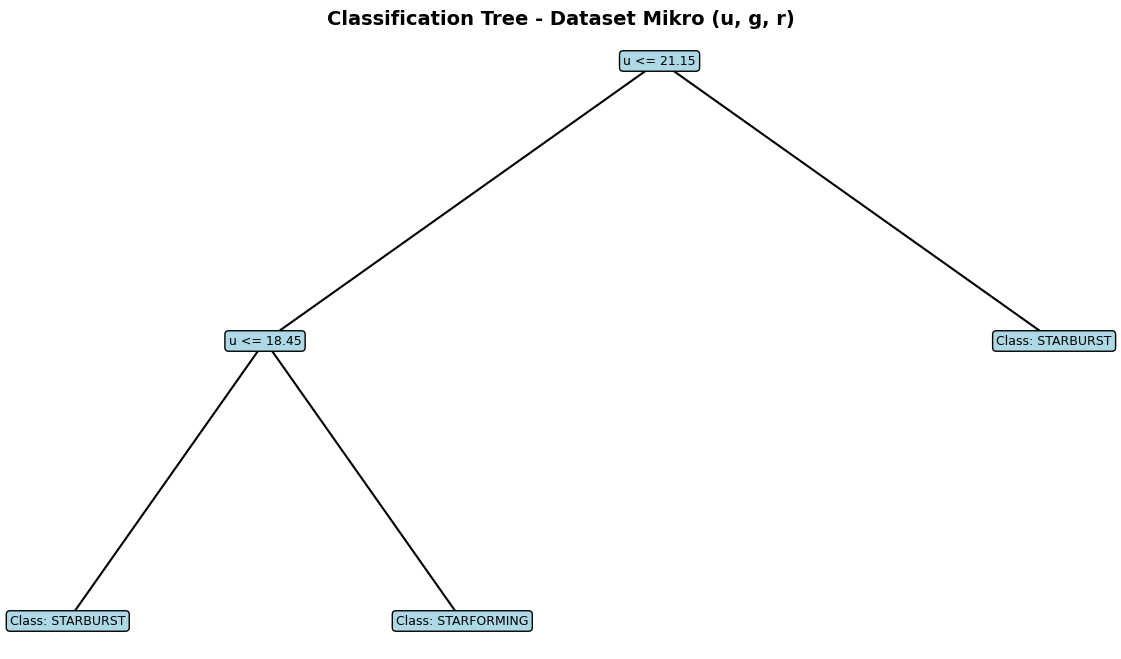

In [28]:
# Visualisasi tree
plt.rc('font', size=9)
plot_tree(clf_mikro.root, feature_names_mikro)
plt.title("Classification Tree - Dataset Mikro (u, g, r)", fontsize=14, fontweight='bold')
plt.show()

### 9f. Prediksi Hardcoded (Tracing)

Melakukan prediksi dengan data hardcoded untuk **menelusuri (tracing)** jalur keputusan pada tree yang sudah dibangun.

In [ ]:
# Data prediksi hardcoded untuk tracing
# Format: [u, g, r]
test_mikro = [
    [19.5, 18.0, 17.2]
]

print("="*60)
print("  TRACING PREDIKSI - Dataset Mikro")
print("="*60)
print(f"\nInput data: u={test_mikro[0][0]}, g={test_mikro[0][1]}, r={test_mikro[0][2]}")
print(f"\n--- Tracing jalur keputusan ---")

# Tracing: telusuri tree dari root ke leaf
node = clf_mikro.root
step = 1
row = test_mikro[0]

while not node.is_leaf():
    feature_name = feature_names_mikro[node.feature_index]
    feature_value = row[node.feature_index]
    threshold = node.threshold
    
    if feature_value <= threshold:
        direction = "KIRI (<=)"
        node = node.left
    else:
        direction = "KANAN (>)"
        node = node.right
    
    print(f"  Step {step}: {feature_name} = {feature_value} vs threshold = {threshold:.4f}  ->  {direction}")
    step += 1

print(f"\n>> Hasil prediksi: {node.value}")

# Prediksi via method predict
pred_mikro = clf_mikro.predict(test_mikro)
print(f">> Verifikasi via predict(): {pred_mikro[0]}")

  TRACING PREDIKSI - Dataset Mikro

Input data: u=19.5, g=18.0, r=17.2

--- Tracing jalur keputusan ---
  Step 1: u = 19.5 vs threshold = 21.1500  ->  KIRI (<=)
  Step 2: u = 19.5 vs threshold = 18.4500  ->  KANAN (>)

>> Hasil prediksi: STARFORMING
>> Verifikasi via predict(): STARFORMING
